In [5]:
import pandas as pd
import numpy as np
tanzania=pd.read_csv("../data/tanzania.csv",skipfooter=10)
tanzania.head()

/tmp/ipykernel_22063/1103256425.py:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  tanzania=pd.read_csv("../data/tanzania.csv",skipfooter=10)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16


In [6]:
# missing value
tanzania.replace(-999,np.nan,inplace=True)
print(f" Messing Value found:\n {tanzania.isnull().sum()}")

 Messing Value found:
 YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
dtype: int64


In [7]:
# date conversion
tanzania["DATE"]=pd.to_datetime(tanzania["YEAR"]*1000+tanzania["DOY"],format= "%Y%j")
tanzania["MONTH"]=tanzania["DATE"].dt.month
tanzania.set_index("DATE",inplace=True)
tanzania.head()



,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,MONTH
DATE,,,,,,,,,,,,,
2015-01-01,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,1
2015-01-02,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,1
2015-01-03,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,1
2015-01-04,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,1
2015-01-05,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,1


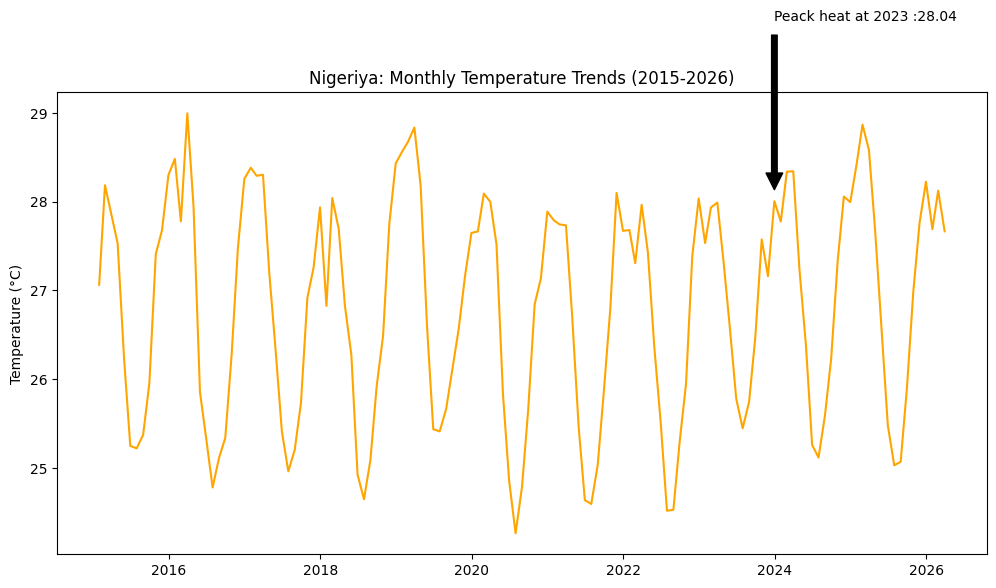

In [8]:
# Monthly Temperature Line Chart
import matplotlib.pyplot as plt
# resample monthely averagy
monthly_temp=tanzania["T2M"].resample('ME').mean()
plt.figure(figsize=(12,6))
plt.plot(monthly_temp,label="Mean Temp ",color='orange')
# annotate the hotest month in 2023
hottest_2023=monthly_temp["2023"].idxmax()
temp_max=monthly_temp['2022'].max()
plt.annotate(f"Peack heat at 2023 :{temp_max:.2f}",
             xy=(hottest_2023,temp_max),
             xytext=(hottest_2023,temp_max+2),
             arrowprops=dict(facecolor='black',shrink=0.05))
plt.title('Nigeriya: Monthly Temperature Trends (2015-2026)')
plt.ylabel('Temperature (°C)')
plt.show()


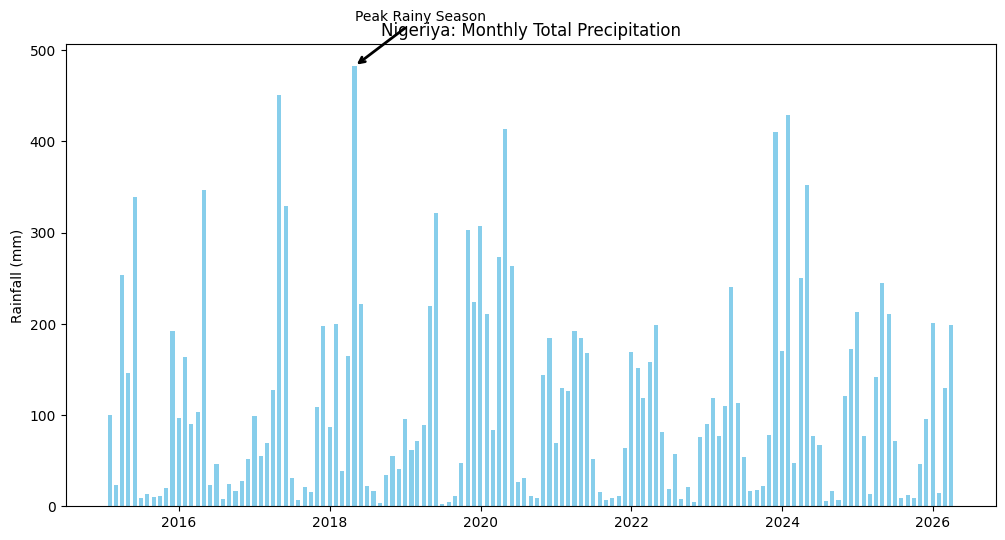

In [9]:
# Resample to Monthly total rainfall
monthly_rain = tanzania['PRECTOTCORR'].resample('ME').sum()

plt.figure(figsize=(12, 6))
plt.bar(monthly_rain.index, monthly_rain.values, color='skyblue', width=20) # type: ignore

# Identify the peak rainy season (example: finding the highest bar)
peak_month = monthly_rain.idxmax()
peak_value = monthly_rain.max()

plt.annotate('Peak Rainy Season', 
             xy=(peak_month, peak_value),  # type: ignore
             xytext=(peak_month, peak_value + 50), # type: ignore
             arrowprops=dict(arrowstyle='->', lw=2))

plt.title('Nigeriya: Monthly Total Precipitation')
plt.ylabel('Rainfall (mm)')
plt.show()